# Analyzing Death Rate Disparities by Race, Sex, and Time in New York City


Overview: For this project, I will be exploring the most common causes of deaths in New York City, focusing on how they vary by sex and race over the period from 2007 to 2021. The dataset, New York City Leading Causes of Death, can be found on the NYC Open Data website.

I will be answering the following 3 questions in my analysis: 

1. Which race/ethnicity groups have the highest age-adjusted death rates for the top leading causes of death in New York City?

2. Within the most affected race/ethnicity groups, how do death rates differ between males and females?

3. How have disparities in age-adjusted death rates between race/ethnicity groups changed over time for the top causes of death?

Dataset: The dataset consists of 7 columns, including the year of death (ranging from 2007 to 2021), leading cause of death, sex, race/ethnicity, number of deaths, death rate, and age-adjusted death rate. 

Note: Age-adjusted death rates are used to fairly compare groups by removing the effects of age. 

Below are the import packages I will be utilizing to clean, transform, manipulate, and complete the analysis:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('New_York_City_Leading_Causes_of_Death_20260420.csv')

Initial Data Inspection:

Upon previewing the dataset using .head() (shown below), you can see that the data is a bit messy. There are inconsistencies in the Sex column where values like “Male” and “M” or “Female” and “F” are mixed. There are also periods used as values, duplicates, extra whitespace, and other non-standard formatting issues.

In the Leading Cause column, I’m planning to remove the ICD (International Classification of Diseases) codes to make the data cleaner and improve grouping and visualization since I'm not doing anything with that information in my analysis.

In [3]:
print(df.head(-25))

      Year                                      Leading Cause     Sex  \
0     2021  Mental and Behavioral Disorders due to Acciden...    Male   
1     2021                                   All Other Causes  Female   
2     2021               Chronic Liver Diseases and Cirrhosis    Male   
3     2021     Diseases of Heart (I00-I09, I11, I13, I20-I51)  Female   
4     2021            Influenza (Flu) and Pneumonia (J09-J18)    Male   
...    ...                                                ...     ...   
2072  2007     Chronic Liver Disease and Cirrhosis (K70, K73)       M   
2073  2007               Aortic Aneurysm and Dissection (I71)       F   
2074  2007                                   All Other Causes       F   
2075  2007                        Diabetes Mellitus (E10-E14)       M   
2076  2007                          Alzheimer's Disease (G30)       F   

                  Race Ethnicity Deaths Death Rate Age Adjusted Death Rate  
0          Other Race/ Ethnicity      9       

In addition, the data types in the columns Deaths, Death Rate, and Age Adjusted Death Rate will have to be converted. I will be converting the 3 columns values into a numeric type (like int or float).

In [4]:
print(df.dtypes)

Year                        int64
Leading Cause              object
Sex                        object
Race Ethnicity             object
Deaths                     object
Death Rate                 object
Age Adjusted Death Rate    object
dtype: object


In [5]:
print(df.columns)

Index(['Year', 'Leading Cause', 'Sex', 'Race Ethnicity', 'Deaths',
       'Death Rate', 'Age Adjusted Death Rate'],
      dtype='object')


# Data Cleaning

In [6]:
df_copy = df.copy()

In [7]:
### Rename Race Ethnicity column to Race/Ethnicity

df_copy = df_copy.rename(columns = {'Race Ethnicity': 'Race/Ethnicity'})

In [8]:
### Keep values in the Sex column consistent with the mapping

df_copy['Sex'] = df_copy['Sex'].replace({'M': 'Male', 'F': 'Female'})

In [9]:
### Replace '.' value with NaN

df_copy = df_copy.replace('.', np.nan)

In [10]:
### Remove ICD Codes with str.replace function and Regex for removing any text in parentheses (including the parentheses themselves) from the Leading Cause column

df_copy['Leading Cause'] = df_copy['Leading Cause'].str.replace(r"\s*\(.*\)", "", regex = True)

In [11]:
### Remove white space in the Race/Ethnicity Column values

df_copy['Race/Ethnicity'] = df_copy['Race/Ethnicity'].str.replace('/ ', '/', regex=False)

In [12]:
### There are quite a few duplicate and lengthy texts in the Race/Ethnicity Column

sorted(df['Race Ethnicity'].unique()) 

['Asian and Pacific Islander',
 'Black Non-Hispanic',
 'Hispanic',
 'Non-Hispanic Black',
 'Non-Hispanic White',
 'Not Stated/Unknown',
 'Other Race/ Ethnicity',
 'White Non-Hispanic']

In [13]:
### Change duplicate and lengthy values in the Race/Ethnicity Column to have consistent labels 

clean_col = {
    'Black Non-Hispanic': 'Non-Hispanic Black',
    'Non-Hispanic Black': 'Non-Hispanic Black',
    
    'White Non-Hispanic': 'Non-Hispanic White',
    'Non-Hispanic White': 'Non-Hispanic White',
    
    'Asian and Pacific Islander': 'Asian/Pacific Islander',
    
    'Other Race/Ethnicity': 'Other',
    'Not Stated/Unknown': 'Unknown'
}

df_copy['Race/Ethnicity'] = df_copy['Race/Ethnicity'].replace(clean_col)

In [14]:
### Result of cleaning the above column

sorted(df_copy['Race/Ethnicity'].unique())

['Asian/Pacific Islander',
 'Hispanic',
 'Non-Hispanic Black',
 'Non-Hispanic White',
 'Other',
 'Unknown']

In this dataset, there are a large number of NaN values in the three columns below. The NaNs represent unknown or unreported information, not actual missing values in the sense of being zero. I also did not fill them with 0, since that would incorrectly imply there were no deaths.

In [15]:
print(df_copy.isna().sum())

Year                         0
Leading Cause                0
Sex                          0
Race/Ethnicity               0
Deaths                     138
Death Rate                 729
Age Adjusted Death Rate    729
dtype: int64


For data type conversion, I used pd.to_numeric() because it handles non-numeric mixed types, which can be an issue when the column was previously stored as an object type. Then I used Int64 for the Deaths column so it does not fail the way a strict int64 would, since int64 requires fully clean numeric values. In contrast, Int64 can handle NaN values while still preserving integer formatting.

In [16]:
### Data Type Conversion for Columns to Numeric: Deaths, Death Rate, Age Adjusted Death Rate

df_copy[['Death Rate', 'Age Adjusted Death Rate']] = df_copy[['Death Rate', 'Age Adjusted Death Rate']].apply(pd.to_numeric, errors = 'coerce')
df_copy['Deaths'] = df_copy['Deaths'].astype('Int64')

Now the dataset look much more cleaner!

In [17]:
print(df_copy.head(-25))

      Year                                      Leading Cause     Sex  \
0     2021  Mental and Behavioral Disorders due to Acciden...    Male   
1     2021                                   All Other Causes  Female   
2     2021               Chronic Liver Diseases and Cirrhosis    Male   
3     2021                                  Diseases of Heart  Female   
4     2021                                          Influenza    Male   
...    ...                                                ...     ...   
2072  2007                Chronic Liver Disease and Cirrhosis    Male   
2073  2007                     Aortic Aneurysm and Dissection  Female   
2074  2007                                   All Other Causes  Female   
2075  2007                                  Diabetes Mellitus    Male   
2076  2007                                Alzheimer's Disease  Female   

              Race/Ethnicity  Deaths  Death Rate  Age Adjusted Death Rate  
0                      Other       9         Na

I converted the data types into the correct numeric types:

In [18]:
print(df_copy.dtypes)

Year                         int64
Leading Cause               object
Sex                         object
Race/Ethnicity              object
Deaths                       Int64
Death Rate                 float64
Age Adjusted Death Rate    float64
dtype: object


In [19]:
print(df_copy.describe())

              Year       Deaths   Death Rate  Age Adjusted Death Rate
count  2102.000000  1964.000000  1373.000000              1373.000000
mean   2014.089439   429.256110    56.258163                53.607305
std       4.333722   827.583725    75.598398                68.109884
min    2007.000000     1.000000     2.400000                 2.500000
25%    2010.000000    25.000000    12.843000                12.338107
50%    2014.000000   140.000000    20.100000                19.800000
75%    2018.000000   317.250000    78.900000                81.500000
max    2021.000000  7050.000000   491.400000               414.594473


# Analysis

Examining the age-adjusted death rates across race/ethnicity groups within leading causes:

In [20]:
### Top Causes by total deaths

top_causes = (df_copy.groupby('Leading Cause')['Deaths']
              .sum()
              .sort_values(ascending = False)
              .head(5)
              .index)

### Compare race/ethnicity within those causes

q1 = (df_copy[df_copy['Leading Cause'].isin(top_causes)]
      .groupby(['Leading Cause','Race/Ethnicity'])['Age Adjusted Death Rate'].mean().reset_index())
        
### Sort and Rank within each Cause

q1_sorted = q1.sort_values(['Leading Cause', 'Age Adjusted Death Rate'], ascending = [True, False])

print(q1_sorted)        

          Leading Cause          Race/Ethnicity  Age Adjusted Death Rate
5      All Other Causes                 Unknown               163.585872
2      All Other Causes      Non-Hispanic Black               153.113634
1      All Other Causes                Hispanic               119.606148
3      All Other Causes      Non-Hispanic White               118.451557
0      All Other Causes  Asian/Pacific Islander                69.627125
4      All Other Causes                   Other                      NaN
7              Covid-19                Hispanic               190.475000
8              Covid-19      Non-Hispanic Black               184.925000
6              Covid-19  Asian/Pacific Islander               110.500000
9              Covid-19      Non-Hispanic White               100.400000
10             Covid-19                   Other                      NaN
11             Covid-19                 Unknown                      NaN
17    Diseases of Heart                 Unknown    

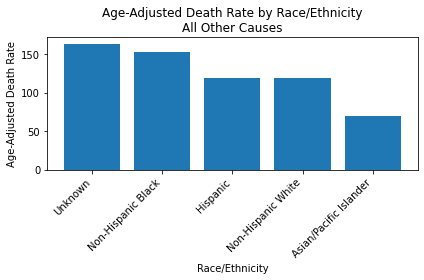

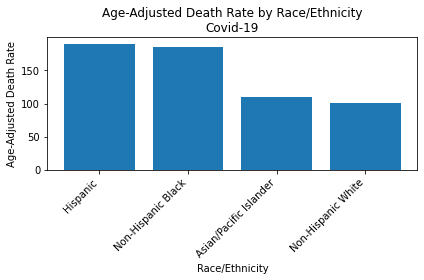

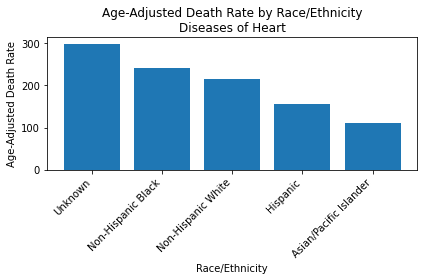

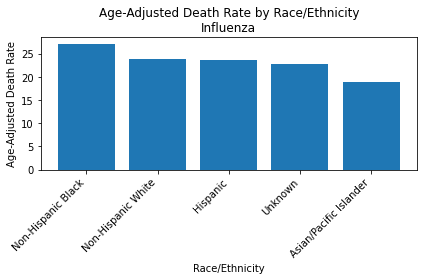

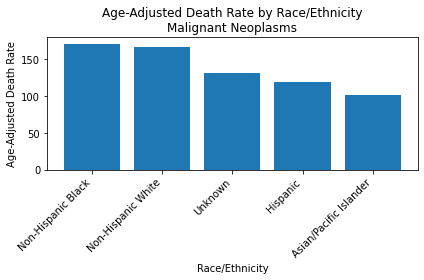

In [21]:
top_causes = q1_sorted['Leading Cause'].unique()

for cause in top_causes:
    temp = q1_sorted[q1_sorted['Leading Cause'] == cause]
    
    plt.figure()
    plt.bar(temp['Race/Ethnicity'], temp['Age Adjusted Death Rate'])
    
    plt.title(f'Age-Adjusted Death Rate by Race/Ethnicity\n{cause}')
    plt.xlabel('Race/Ethnicity')
    plt.ylabel('Age-Adjusted Death Rate')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Displayed above, we can see that the highest at-risk demographic group across several leading causes of death such as Heart Disease, Malignant Neoplasms, All Other Causes, and Influenza is the Non-Hispanic Black population. The exception is COVID-19, where Hispanic individuals show the highest age-adjusted death rates, with Non-Hispanic Black individuals still remaining among the most affected groups in New York City.

According to the standard epidemiological scaling convention (CDC: https://www.cdc.gov/nchs/hus/sources-definitions/rate.htm), age-adjusted death rates are conveyed as mortality per 100,000 population. This means that the value 240.924422 shown in the output and visualizations for diseases of the heart among Non-Hispanic Black individuals corresponds to about 241 deaths per 100,000 people, after adjusting for differences in age distribution across groups. This makes the comparisons between demographic groups more fair and meaningful.

I also included the Unknown category in both the visuals and the code to show that a noticeable amount of race/ethnicity data was not reported or recorded. This missing information could potentially introduce some bias into the results, since excluding or misclassifying these cases may affect the overall distribution of leading causes of death across different demographic groups.

Differences in Age-Adjusted Death Rates Between Males and Females Within the Highest-Risk Demographic Groups:

In [22]:
### Create top leading causes for affected groups 

top = q1_sorted.groupby('Leading Cause').head(1)
top_groups = top[['Leading Cause', 'Race/Ethnicity']]

### Filter Original Data

df_q2 = df_copy.merge(top_groups, on = ['Leading Cause', 'Race/Ethnicity'])

### Compare By Sex

q2 = (df_q2.groupby(['Leading Cause', 'Race/Ethnicity', 'Sex'])['Age Adjusted Death Rate']
      .mean()
      .unstack())

### Gender Gap

q2['Gap (Male - Female)'] = q2['Male'] - q2['Female']

print(q2)

Sex                                         Female        Male  \
Leading Cause       Race/Ethnicity                               
All Other Causes    Unknown              94.641463  232.530281   
Covid-19            Hispanic            121.500000  259.450000   
Diseases of Heart   Unknown             194.315070  404.179237   
Influenza           Non-Hispanic Black   21.244228   32.980936   
Malignant Neoplasms Non-Hispanic Black  145.144305  197.507757   

Sex                                     Gap (Male - Female)  
Leading Cause       Race/Ethnicity                           
All Other Causes    Unknown                      137.888818  
Covid-19            Hispanic                     137.950000  
Diseases of Heart   Unknown                      209.864167  
Influenza           Non-Hispanic Black            11.736708  
Malignant Neoplasms Non-Hispanic Black            52.363452  


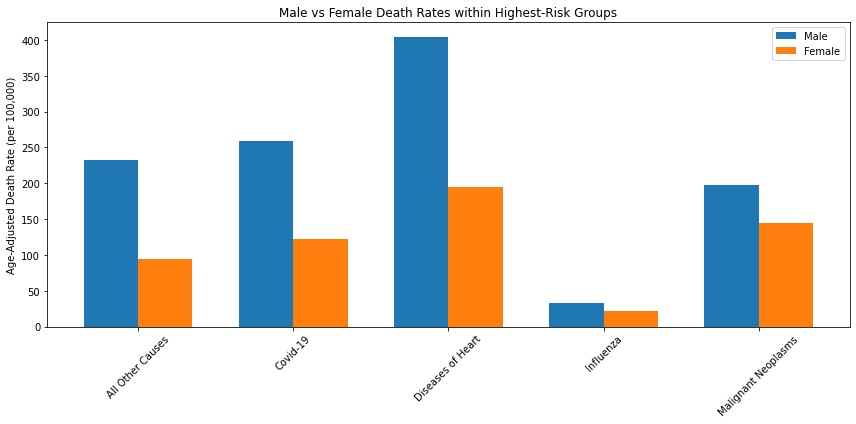

In [23]:
q2_plot = q2.reset_index()

plt.figure(figsize=(12, 6))

x = range(len(q2_plot))

width = 0.35

plt.bar(x, q2_plot['Male'], width=width, label='Male')
plt.bar([i + width for i in x], q2_plot['Female'], width=width, label='Female')

plt.xticks([i + width/2 for i in x], q2_plot['Leading Cause'], rotation=45)
plt.ylabel('Age-Adjusted Death Rate (per 100,000)')
plt.title('Male vs Female Death Rates within Highest-Risk Groups')
plt.legend()

plt.tight_layout()
plt.show()

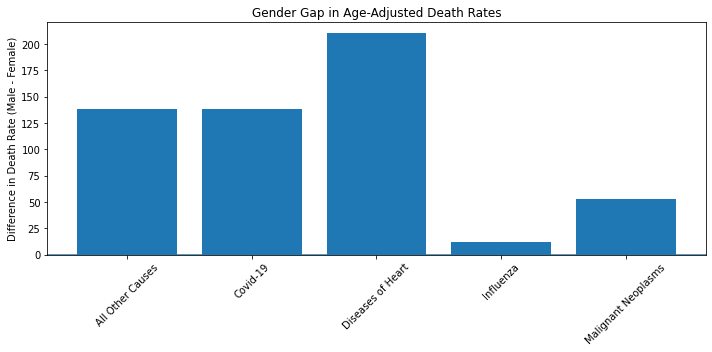

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(q2_plot['Leading Cause'], q2_plot['Gap (Male - Female)'])

plt.axhline(0)  # baseline

plt.xticks(rotation=45)
plt.ylabel('Difference in Death Rate (Male - Female)')
plt.title('Gender Gap in Age-Adjusted Death Rates')

plt.tight_layout()
plt.show()

Looking at the results and comparing genders across leading causes of death, men consistently have higher mortality risk in all categories. The largest difference appears in heart disease, where the age-adjusted death rate for men is about 404 per 100,000 people, compared to 194 per 100,000 for women - nearly twice as high. This further highlights the disparity between genders, as shown in the “Gender Gap in Age-Adjusted Death Rates” chart, where all values are positive. This indicates that males have higher death rates across every category, with no instances where female rates exceed those of males.

Additionally, the observed gaps show that, for causes such as All Other Causes, COVID-19, and Diseases of the Heart, female death rates do not reach even half of the male rates. While Malignant Neoplasms and Influenza show smaller differences, the overall pattern of higher mortality among men remains consistent. These results suggest a persistent gender disparity in health outcomes across multiple leading causes of death. 

Age-adjusted Death Rates between Race/Ethnicity Groups over Time For Top Leading Causes:

In [25]:
### Filter to top causes

top_causes3 = q1_sorted['Leading Cause'].unique()
df_q3 = df_copy[df_copy['Leading Cause'].isin(top_causes3)]

### Group by time, cause, and race

q3 = (df_q3.groupby(['Year', 'Leading Cause', 'Race/Ethnicity'])['Age Adjusted Death Rate']
      .mean()
      .reset_index())

### Measure disparity

disparity = (q3.groupby(['Year', 'Leading Cause'])['Age Adjusted Death Rate']
             .agg(lambda x: x.max() - x.min())
             .reset_index(name = 'Disparity'))
      
pd.set_option('display.max_rows', None)

print(disparity)

    Year        Leading Cause   Disparity
0   2007     All Other Causes   85.000000
1   2007    Diseases of Heart  164.200000
2   2007            Influenza   12.750000
3   2007  Malignant Neoplasms   78.400000
4   2008     All Other Causes   83.000000
5   2008    Diseases of Heart  151.900000
6   2008            Influenza    8.450000
7   2008  Malignant Neoplasms   89.700000
8   2009     All Other Causes   90.000000
9   2009    Diseases of Heart  139.250000
10  2009            Influenza    5.700000
11  2009  Malignant Neoplasms   84.700000
12  2010     All Other Causes   77.400000
13  2010    Diseases of Heart  141.100000
14  2010            Influenza    6.900000
15  2010  Malignant Neoplasms   87.600000
16  2011     All Other Causes   84.000000
17  2011    Diseases of Heart  125.550000
18  2011            Influenza    9.100000
19  2011  Malignant Neoplasms   85.600000
20  2012     All Other Causes   78.800000
21  2012    Diseases of Heart  133.250000
22  2012            Influenza   12

The table above shows the highest and lowest leading causes of death by race/ethnicity for each year from 2007 to 2021 based on age-adjusted death rates. Additionally, each value in the “Disparity” column measures the differences in death rates across race/ethnicity for a given year and cause of death.

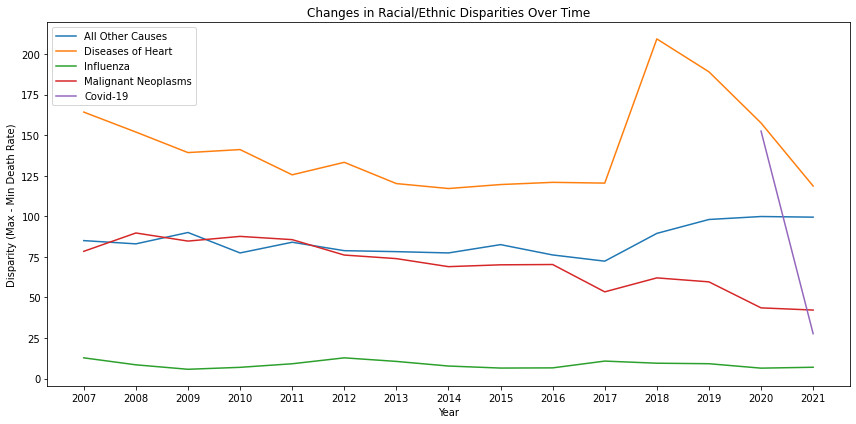

In [26]:
plt.figure(figsize=(12, 6))

for cause in disparity['Leading Cause'].unique():
    subset = disparity[disparity['Leading Cause'] == cause]
    plt.plot(subset['Year'], subset['Disparity'], label=cause)

plt.xlabel('Year')
plt.ylabel('Disparity (Max - Min Death Rate)')
plt.title('Changes in Racial/Ethnic Disparities Over Time')

plt.xticks(range(2007, 2022))

plt.legend()
plt.tight_layout()
plt.show()

In this line chart, Diseases of Heart remains the number 1 cause of death disparity consistently over time. From 2017 to 2018, there is a drastic upward trend in heart disease, increasing from about 120.44 to 209.30 per 100,000 individuals in New York City. Then from 2018 to 2019, after reaching the peak of 209.30, the disparity decreases slightly to about 189.02. These two years stand out as an outlier period, showing the largest magnitude change compared to all other causes.

In the earlier period from 2007 to 2014, there is a steady decline from about 164.20 down to 117.10, suggesting some improvement in inequality over time. From 2015 to 2017, the disparity levels for heart disease stay relatively stable, hovering around the 118–121 range. In 2020, the trend increases again to about 157.50, before dropping in 2021 to around 118.65, which is close to earlier baseline levels seen in the mid-2010's.

When comparing other leading causes like All Other Causes and Malignant Neoplasms, their values stay relatively closer in range and much more stable overall, with smaller fluctuations and gradual changes over time. Malignant Neoplasms generally shows a slight downward trend in the later years, while All Other Causes remains fairly steady with moderate variation.

COVID-19 in 2020 is a major exception, where its disparity is close to Heart Disease (152.50 vs. 157.50). However, in 2021, COVID-19 drops significantly to about 27.65, showing a sharp decrease across demographic groups.

Lastly, Influenza does not show any significant disparity patterns, with values staying consistently low and flat throughout the years, roughly in the 5–12 range.

# Conclusion

Key Findings:

1. Heart disease is the leading cause of death disparity across all demographic groups.
2. The most at-risk ethnic group is Non-Hispanic Black across the top five causes, with the exception of COVID-19, where rates are comparable to the Hispanic population.
3. Males disproportionately exceed females in the leading causes of death, showing a noticeable disparity gap that is often close to twice the magnitude.
4. Diseases of Heart consistently has the highest mortality disparity rate year over year from 2007 to 2021.

Limitations:

The dataset appears to be missing important details that could provide a more accurate representation of population health and leading causes of death. In particular, factors such as socioeconomic status are not included, even though they likely play a significant role in mortality disparities.

Additionally, the category “All Other Causes” is too broad and vague, which limits deeper analysis. Grouping multiple causes together makes it difficult to identify specific contributors to mortality across different racial and ethnic groups. This aggregation may also distort interpretation by understating the true significance of these underlying causes.